<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/excercice_model_fitting_and_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Uncertainty - modelling and slection**

This Colab notebook provides an introduction to uncertainty modeling, covering aleatoric models and an introduction to model selection.  

**THE STUDENTS WILL**:
1. Generate n=1000 data points using the DGM provided
2. Explore the data (plot it, print mean, standard deviation)
3. Fit a (parametric) GMM model and a (non-parametric) KDE model
4. Repeat the GMM fitting for a list of [2, 10, 15, 20, 60, 80] components. compare likelihood, BIC, and AIC.
5. Same for the KDE different bandwidth. 6. Visualization + discussion on the best model


## 🎯 **Data Generation Mechanism (DGM)**  

Before working with probabilistic models, we need some data.

We will start with two synthetic datasets.  

### 🔹 `data_generation_mechanism()` function  
This function simulates an experiment where samples are drawn and datasets generated.

We have three different sampling mechanisms:  

1️⃣ **Normal Distribution** – Generates Gaussian-distributed data.  
2️⃣ **Blobs (Clusters of Points)** – Useful for classification tasks.  
3️⃣ **Two Moons Dataset** – A non-linearly separable dataset often used for clustering.   

---

In [163]:
# Here we import useful packages and methods
# math and statistical tools
import numpy as np
import math
import scipy.stats as stats
import numpy.random as random

# tools for visualization and plotting
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn as skl
from sklearn.datasets import make_blobs, make_moons
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

In [164]:
def data_generation_mechanism(n_samples: int = 100,
                              n_dimensions: int = 1,
                              type='normal',
                              add_noise: bool = False,
                              nose_level: float = 0.5):
    """
    Generates a matrix of random data with specified number of samples and dimensions.

    Parameters:
    - n_samples (int): Number of samples (rows of the matrix).
    - n_dimensions (int): Number of dimensions (columns of the matrix).
    - type (str): The type of data distribution ('normal', 'blobs', 'two_moons').

    Returns:
    - np.ndarray: A matrix with shape (n_samples, n_dimensions), filled with random data.
    """
    # Default to 'normal' if no type is specified
    if type is None:
        type = 'normal'

    if type == 'normal':
        # For normal distribution, we use a multivariate normal distribution
        mean = [0] * n_dimensions  # Mean vector
        cov = np.eye(n_dimensions)  # Identity covariance matrix (no correlation)
        data_matrix = np.random.multivariate_normal(mean, cov, size=n_samples)

    elif type == 'blobs':
        # Generate data from blobs (clusters of points)
        data_matrix, _ = make_blobs(n_samples=n_samples,
                                    n_features=n_dimensions,
                                    centers=5,        # play with the number of blobs if you like
                                    random_state=42)

    elif type == 'two_moons':
        # Generate two moons dataset (non-linear)
        data_matrix, _ = make_moons(n_samples=n_samples, noise=0.1, random_state=42)

    else:
        raise ValueError(f"Unsupported data type: {type}")

    if add_noise:
        # Add Gaussian noise to the data
        noise = np.random.normal(0, nose_level, size=(n_samples, n_dimensions))
        data_matrix += noise

    return data_matrix


## 🔬 **Data Visualization Examples**  

We generate and visualize different datasets using:  
- **Clusters of points (blobs)**  
- **Two moons dataset** (with and without noise)  

Additionally, we explore the effect of different **noise levels** on data distribution.  



In [165]:
# Data Generation Mechanism:
# Data Generation Mechanism:
n_samples = 1000  # Number of samples
n_dimensions = 2  # Number of dimensions
data_blobs = data_generation_mechanism(n_samples, n_dimensions, type='blobs')      # Generate data of type 'blobs'
data_moons = data_generation_mechanism(n_samples, n_dimensions, type='two_moons', add_noise=False)

### 📊 **Plots Included**  
✔️ Scatter plots of generated data  
✔️ Effect of noise on the two moons dataset     

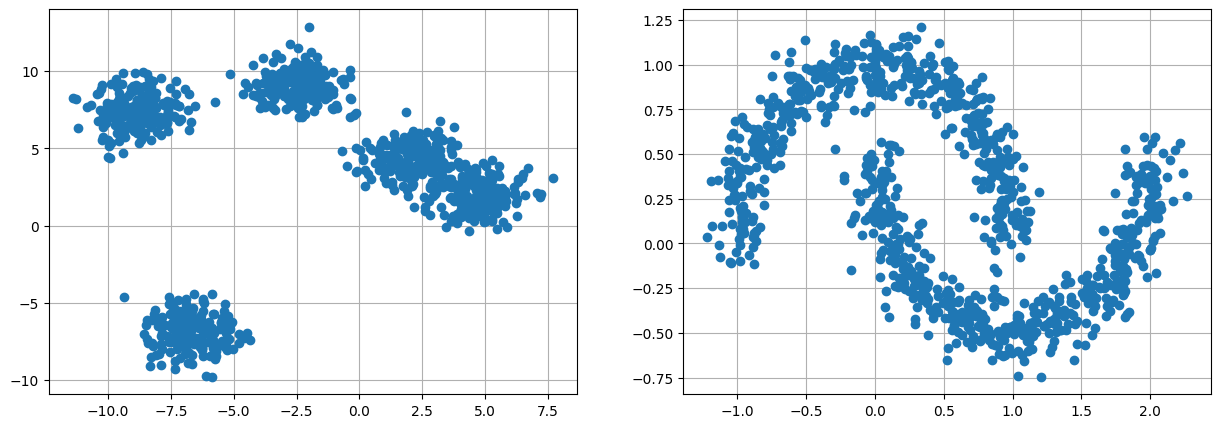

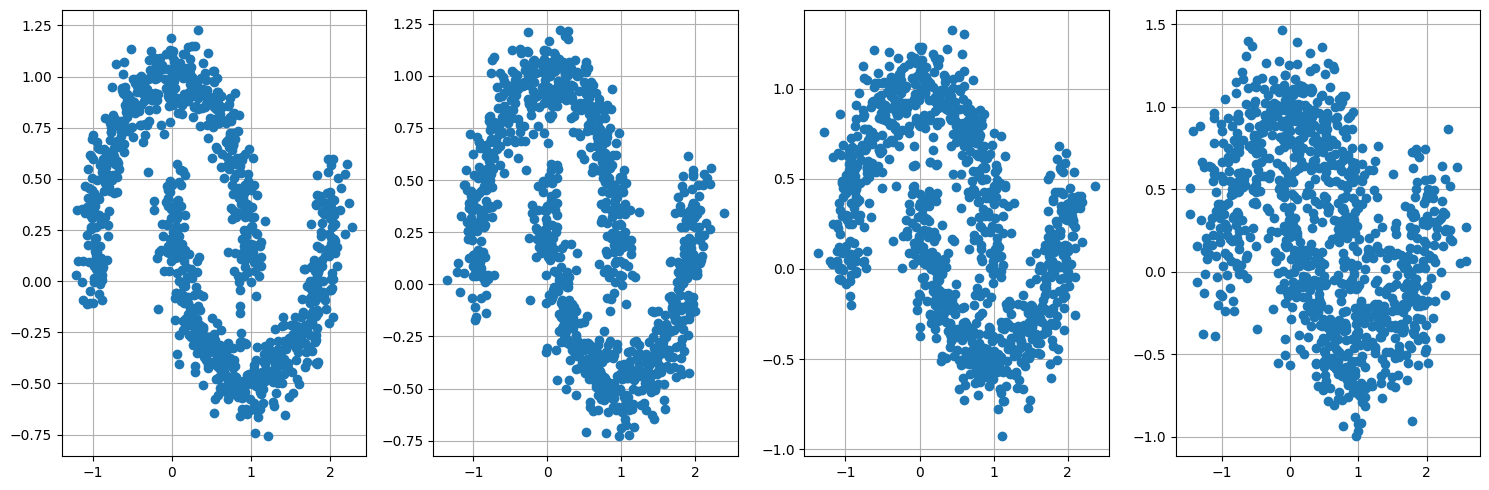

In [166]:
# Scatter plot visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(data_blobs[:, 0], data_blobs[:, 1], 'o', label='blobs')
ax[1].plot(data_moons[:, 0], data_moons[:, 1], 'o', label='two_moons')
ax[0].grid()
ax[1].grid()
plt.show()


# Generating mechanism + additional noise
noise_levels = [0.01, 0.05, 0.1, 0.2]
fig, axs = plt.subplots(1, len(noise_levels), figsize=(15, 5))
for noise_level, ax in zip(noise_levels, axs):
    data_moons_noise = data_generation_mechanism(n_samples, n_dimensions, type='two_moons', add_noise=True, nose_level=noise_level)
    ax.plot(data_moons_noise[:, 0], data_moons_noise[:, 1], 'o', label=f'two_moons (noise={noise_level})')
    ax.grid()
plt.tight_layout()
plt.show()


# SELECT NOW WHICH DATA YOU WOULD LIKE TO WORK WITH

In [167]:
data = data_blobs  # select the data you wish to explore
#  data = data_moons
# data = data_moons_noise

## **Fitting, visualization & comparison of models**:

**Raw Data:** Displays the actual points generated from the "Two Moons" dataset, which may have non-linear separability.

**GMM PDF:** Fit and visualize how well the Gaussian Mixture Model (GMM) approximates the underlying data distribution with $M=2$ Gaussian components.

```
M = 2 # two gaussian mixtures
GMM = GaussianMixture(n_components=M, covariance_type='full', random_state=42)
GMM.fit(data) # fit the model
```

**KDE Density:** Fit and visualize how well the Kernel Density Estimator (KDE) approximates the underlying data distribution with a bandwidth $h=10$

```
  h = 10
  kde = KernelDensity(kernel='gaussian', bandwidth=h)
  kde.fit(data)
```
**COMPUTE THE LOG-LIKELIHOOD PER SAMPLE**



**NOTE:**

1️⃣ `score_samples(DATA)`

Returns the log-density evaluated at each sample:
$\log f(u^{(i)})  $

2️⃣ `score(DATA)`
Returns the average log-likelihood of the data under the model:
$\frac{1}{N} \sum_{i=1}^N \log f(u^{(i)})  $


Log-Lik GMM with M=2 component:  -5213.218311579878
Log-Lik KDE with h=10.0 bandwith :  -6928.286670943598


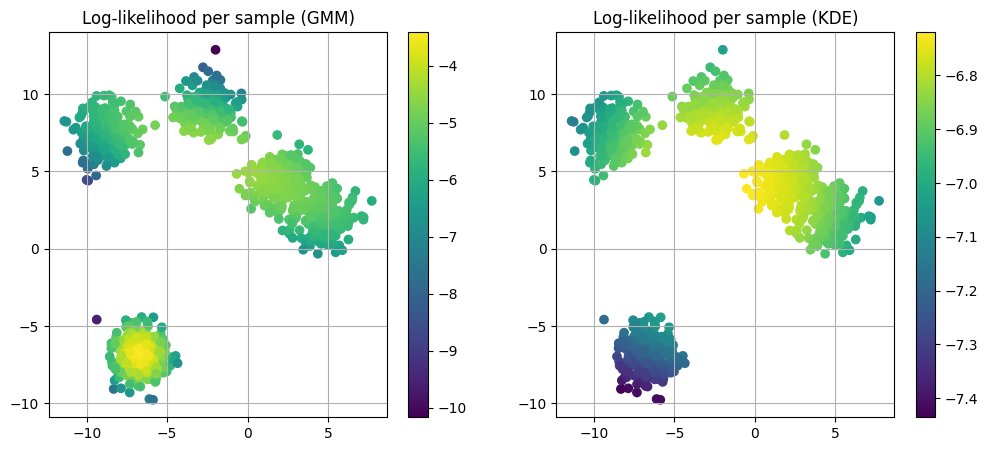

In [168]:


M = 2 # two gaussian mixtures for the GMM model
GMM = GaussianMixture(n_components=M, covariance_type='full', random_state=42)
GMM.fit(data) # fit the model

h = 10.0 # smoothing parameter for the KDE model
KDE = KernelDensity(kernel='gaussian', bandwidth=h)
KDE.fit(data)

# Evaluate log-likelihood per sample and total
def evaluate_log_likelihood(GMM, KDE, data):
  LL_GMM_per_sample = GMM.score_samples(data)
  LL_KDE_per_sample = KDE.score_samples(data)
  LL_GMM = np.sum(LL_GMM_per_sample)
  LL_KDE = np.sum(LL_KDE_per_sample)
  print(f'Log-Lik GMM with M={M} component: ', LL_GMM)
  print(f'Log-Lik KDE with h={h} bandwith : ', LL_KDE)
  return LL_GMM_per_sample, LL_KDE_per_sample, LL_GMM, LL_KDE

# apply logliklihood method, print log-lik scores
LL_GMM_per_sample, LL_KDE_per_sample, LL_GMM, LL_KDE = evaluate_log_likelihood(GMM, KDE, data)


# VISUALIZATION
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)# GMM likelihood
plt.scatter(data[:,0], data[:,1], c=LL_GMM_per_sample, cmap='viridis')
plt.title("Log-likelihood per sample (GMM)")
plt.colorbar()  # add colorbar likelihood value individual samples
plt.grid()  # add grid better visual
plt.subplot(1,2,2)# KDE likelihood
plt.scatter(data[:,0], data[:,1], c=LL_KDE_per_sample, cmap='viridis')
plt.title("Log-likelihood per sample (KDE)")
plt.colorbar()
plt.grid()
plt.show()




**Iso-Probability Curves:** Helps compare how GMM and KDE models capture data distributions and their density levels.


```
  # Create a mesh grid for density visualization
  n_grid_points=200
  x = np.linspace(min(data[:, 0])-1, max(data[:, 0])+1, n_grid_points)
  y = np.linspace(min(data[:, 1])-1, max(data[:, 1])+1, n_grid_points)
  X, Y = np.meshgrid(x, y)
  grid_points = np.column_stack([X.ravel(), Y.ravel()])

  # Evaluate densities
  log_likelihood = model.score_samples(grid_points)
  pdf_density = np.exp(log_likelihood).reshape(X.shape)
  # use the ax.contour(X, Y, pdf_density, levels=20, colors='blue', linestyles='solid') function

```



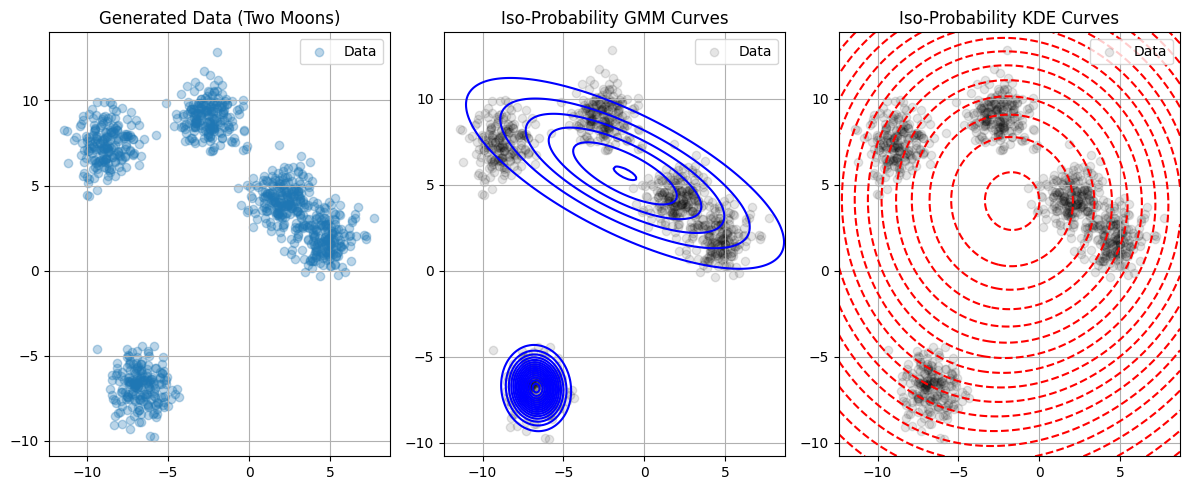

In [169]:
def plot_iso_probability_curves(GMM, KDE, data, n_grid_points=200):
  # simple function to show iso-probabilty curves of the two model
  x = np.linspace(min(data[:, 0])-1, max(data[:, 0])+1, n_grid_points)
  y = np.linspace(min(data[:, 1])-1, max(data[:, 1])+1, n_grid_points)
  X, Y = np.meshgrid(x, y)
  grid_points = np.column_stack([X.ravel(), Y.ravel()])

  # Evaluate densities (PDF values)
  gmm_density = np.exp(GMM.score_samples(grid_points)).reshape(X.shape)
  kde_density = np.exp(KDE.score_samples(grid_points)).reshape(X.shape)

  # Visualize results
  fig, ax = plt.subplots(1, 3, figsize=(12, 5))

  # Raw data
  ax[0].scatter(data[:, 0], data[:, 1], alpha=0.3, label="Data")
  ax[0].set_title("Generated Data (Two Moons)")
  ax[0].legend()

  # Iso-probability density curves
  ax[1].contour(X, Y, gmm_density, levels=20, colors='blue', linestyles='solid')
  ax[2].contour(X, Y, kde_density, levels=20, colors='red', linestyles='dashed')
  ax[1].scatter(data[:, 0], data[:, 1], alpha=0.1, color="black", label="Data")
  ax[2].scatter(data[:, 0], data[:, 1], alpha=0.1, color="black", label="Data")
  ax[1].set_title("Iso-Probability GMM Curves")
  ax[2].set_title("Iso-Probability KDE Curves")
  ax[2].legend()
  ax[1].legend()

  [a.grid() for a in ax]
  plt.tight_layout()
  plt.show()

# use it now
plot_iso_probability_curves(GMM, KDE, data)

## Visually we cal already tell these may not be very good models
## how can we do betteR? Let us try to **fit and select** a better model but not overshoot it

Log-Lik GMM with M=4 component:  -4412.287932386372
Log-Lik KDE with h=0.5 bandwith :  -4338.375192527191


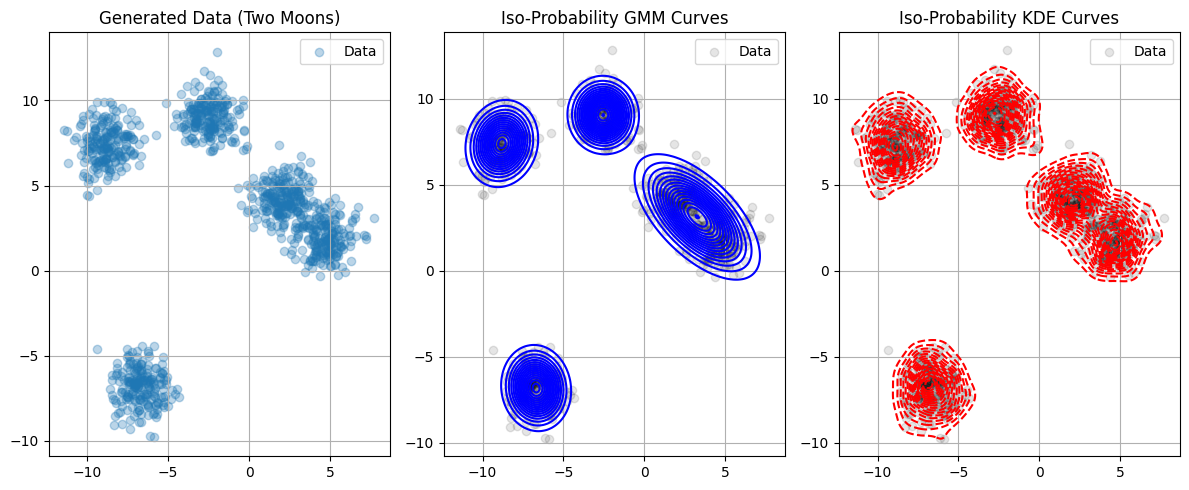

In [174]:
M = 4 # MORE MIXTURES -> MORE REPRESENTATRION POWER -> MORE COMPLEX -> RISK OVERFITTING
GMM = GaussianMixture(n_components=M, covariance_type='full', random_state=42)
GMM.fit(data) # fit the model

h = 0.5 # LOWER BANDWIDTH -> LESS SMOOTHING -> RISK OF OVERFITTING
KDE = KernelDensity(kernel='gaussian', bandwidth=h)
KDE.fit(data)

# apply logliklihood method, print log-lik scores
LL_GMM_per_sample, LL_KDE_per_sample, LL_GMM, LL_KDE = evaluate_log_likelihood(GMM, KDE, data)


#visualize
plot_iso_probability_curves(GMM, KDE, data)




**Model selection:** Compare AIC, BIC, and likelihood of different models. Select a list of bandwidths (KDE) and list with a number of mixtures (GMM), repeat the fitting, evaluate goodness of fit vs complexity.


```
  kde.aic(data) # on fitted model
  kde.bic(data)
```

Note that the AIC

$AIC = 2k -2 \log(L)$

whilst

$BIC = \log(N)k - 2 \log(L)$

* $k$ = nuber of model parameters
* $N$ = number of samples
* $log(L)$ = the log-likelihood of the model

Hence, the BIC penalty per parameter $k$ is much larger than AIC.
* AIC: **weak penalty** for data set with $N$ large
* BIC: **strong penalty** for data set with $N$ large

Log-Lik GMM with M=2 component:  -5213.218311579878
AIC score of the GMM with M=2 component:  10448.436623159756
BIC score of the GMM with M=2 component:  10502.421931228559
Log-Lik GMM with M=3 component:  -4642.521669783983
AIC score of the GMM with M=3 component:  9319.043339567967
BIC score of the GMM with M=3 component:  9402.475179310662
Log-Lik GMM with M=4 component:  -4412.287932386372
AIC score of the GMM with M=4 component:  8870.575864772743
BIC score of the GMM with M=4 component:  8983.454236189333
Log-Lik GMM with M=5 component:  -4358.301038064803
AIC score of the GMM with M=5 component:  8774.602076129606
BIC score of the GMM with M=5 component:  8916.926979220088
Log-Lik GMM with M=6 component:  -4357.4014403951805
AIC score of the GMM with M=6 component:  8784.802880790361
BIC score of the GMM with M=6 component:  8956.574315554735
Log-Lik GMM with M=7 component:  -4351.97838169723
AIC score of the GMM with M=7 component:  8785.95676339446
BIC score of the GMM with M

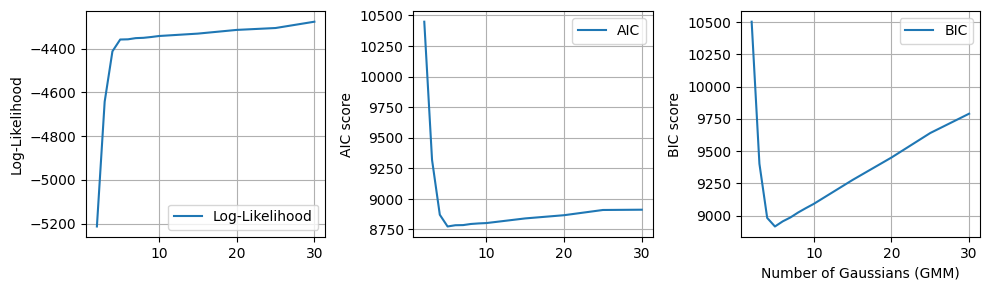

FOR THE SELECTED DATA SET, THE BEST NUMBER OF GAUSSIAN COMPONENTS IS ...🥁🥁🥁🥁🥁... M= 5


GaussianMixture(n_components=5, random_state=42)

In [171]:
AIC_list =[]
BIC_list = []
LL_list = []

# print log-likelihood
number_of_gaussians_list = [2,3,4,5,6,7,8,9,10,15,20,25,30]
for M in number_of_gaussians_list:

  GMM = GaussianMixture(n_components=M, covariance_type='full', random_state=42)
  GMM.fit(data) # fit the GMM model

  LL = np.sum(GMM.score_samples(data) ) # Log-Likelihood
  AIC = GMM.aic(data) # AIC score
  BIC = GMM.bic(data) # BIC score

  LL_list.append(LL)
  AIC_list.append(AIC)
  BIC_list.append(BIC)

  print(f'Log-Lik GMM with M={M} component: ', LL)
  print(f'AIC score of the GMM with M={M} component: ', AIC)
  print(f'BIC score of the GMM with M={M} component: ', BIC)


fig, axes = plt.subplots(1, 3, figsize=(10,3), sharex=True)

# Log-likelihood
axes[0].plot(number_of_gaussians_list, LL_list, label='Log-Likelihood')
axes[0].set_ylabel('Log-Likelihood')
axes[0].legend()
axes[0].grid()

# AIC
axes[1].plot(number_of_gaussians_list, AIC_list, label='AIC')
axes[1].set_ylabel('AIC score')
axes[1].legend()
axes[1].grid()

# BIC
axes[2].plot(number_of_gaussians_list, BIC_list, label='BIC')
axes[2].set_xlabel('Number of Gaussians (GMM)')
axes[2].set_ylabel('BIC score')
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()


print('FOR THE SELECTED DATA SET, THE BEST NUMBER OF GAUSSIAN COMPONENTS IS ...🥁🥁🥁🥁🥁... M=', number_of_gaussians_list[np.argmin(BIC_list)])

M = number_of_gaussians_list[np.argmin(BIC_list)] # BEST MODEL M
best_gmm = GaussianMixture(n_components=M, covariance_type='full', random_state=42)
best_gmm.fit(data) # fit the model


In [172]:
LL_list = []

# print log-likelihood
bandwidth_list = [2,3,4,5,6,7,8,9,10,15,20,25,30,50]
for h in bandwidth_list:

  KDE = KernelDensity(kernel='gaussian', bandwidth=h)
  KDE.fit(data)

  LL = np.sum(KDE.score_samples(data) ) # Log-Likelihood
  # BIC = KDE.bic(data) # BIC score # ❌ not implemented  --> KDE IS NON PARAMETRIC
  LL_list.append(LL)

  print(f'Log-Lik KDE with h={h} bandwidth: ', LL)



# KernelDensity does not implement .bic() or .aic() since KDE is a nonparametric model and the number of parameters is not defined.
# The standard approach is cross-validation for bandwidth (empirical validation):

from sklearn.model_selection import GridSearchCV
params = {'bandwidth': np.logspace(-2,1,20)}
grid = GridSearchCV(KernelDensity(kernel='gaussian'), params)
grid.fit(data)

best_kde = grid.best_estimator_
print('FOR THE SELECTED DATA SET, THE BEST BANDWIDTH IS ...🥁🥁🥁🥁🥁... h=', best_kde.bandwidth)

Log-Lik KDE with h=2 bandwidth:  -5101.696365879799
Log-Lik KDE with h=3 bandwidth:  -5567.150362990513
Log-Lik KDE with h=4 bandwidth:  -5916.7712483489595
Log-Lik KDE with h=5 bandwidth:  -6181.125886304362
Log-Lik KDE with h=6 bandwidth:  -6380.078941789518
Log-Lik KDE with h=7 bandwidth:  -6538.267410551497
Log-Lik KDE with h=8 bandwidth:  -6676.131993436302
Log-Lik KDE with h=9 bandwidth:  -6804.664798615582
Log-Lik KDE with h=10 bandwidth:  -6928.286670943598
Log-Lik KDE with h=15 bandwidth:  -7493.721037691216
Log-Lik KDE with h=20 bandwidth:  -7969.135128751887
Log-Lik KDE with h=25 bandwidth:  -8366.576803509297
Log-Lik KDE with h=30 bandwidth:  -8703.99149665788
Log-Lik KDE with h=50 bandwidth:  -9685.157264473804
FOR THE SELECTED DATA SET, THE BEST BANDWIDTH IS ...🥁🥁🥁🥁🥁... h= 0.5455594781168517


## PLOT THE BEST MODELS

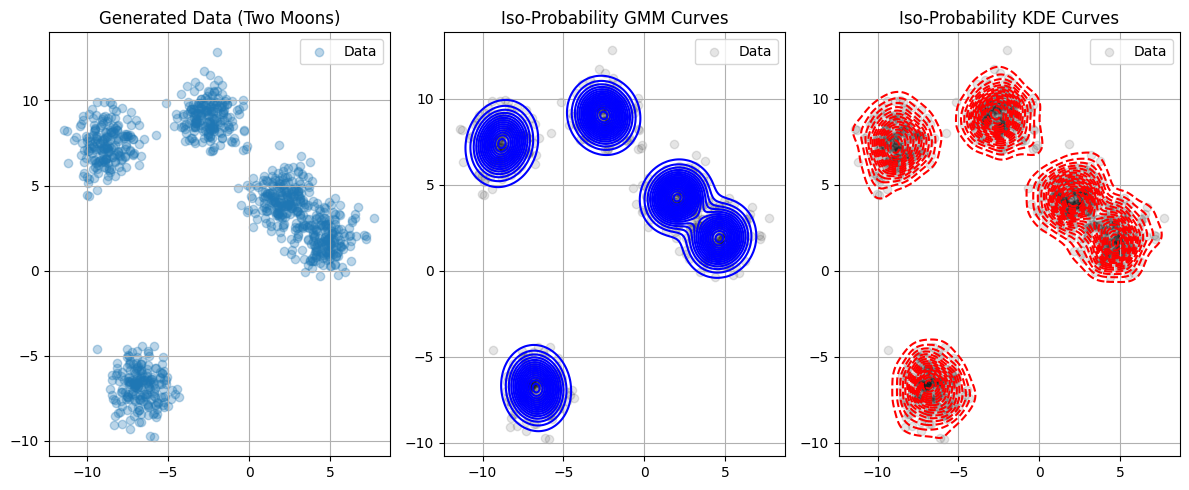

In [173]:
# use now the plotter to visualize the best models
plot_iso_probability_curves(best_gmm, best_kde, data)